# Генерируем данные

In [33]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

np.random.seed(42)
N = 1200

In [34]:
# Пол: 1 = мужчина, 0 = женщина
isMale = np.random.binomial(1, 0.50, N)

# Опыт работы (лет), от 0 до 40
experience = np.clip(np.random.normal(10, 5, N), 0, 40)

# Образование (лет обучения), обрезан до [8, 22]
education = np.clip(np.random.normal(14, 3, N), 8, 22)

# Проживание в областном центре: 1 = да, 0 = нет
isUrban = np.random.binomial(1, 0.60, N)

# Инструмент: возраст 50+: 1 = да, 0 = нет
isAge50 = np.random.binomial(1, 0.30, N)

# Ненаблюдаемая мотивация (стандартная нормаль)
motivation = np.random.normal(0, 1, N)

log_odds_training = (
    -1.2
    + 0.8  * isAge50        
    + 0.5  * motivation   
    + 0.1  * education    
    + 0.2  * isUrban        
)
p_training = 1 / (1 + np.exp(-log_odds_training))
training = np.random.binomial(1, p_training, N)

# Логарифм зарплаты — линейная функция всех факторов
eps = np.random.normal(0, 0.15, N)

ln_wage = (
    6.5
    + 0.08 * training
    + 0.02 * experience
    + 0.06 * education
    + 0.15 * isMale
    + 0.12 * isUrban 
    + 0.10 * motivation
    + eps
)

wage = np.exp(ln_wage)

df = pd.DataFrame({
    "wage":        wage.round(2), 
    "training":    training, 
    "isMale":      isMale, 
    "experience":  experience.round(1), 
    "education":   education.round(1), 
    "isUrban":     isUrban, 
    "isAge50":       isAge50, 
    "motivation":  motivation.round(4), 
})



In [35]:
train_df, test_df = train_test_split(df, test_size=0.25, random_state=42)

---

# 3 

In [36]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.model_selection import cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler

In [37]:
TEST_SIZE = 0.25
RANDOM_STATE = 42
CV_FOLDS = 5

In [38]:
y_train = train_df["training"]
x_train = train_df.drop(columns=["training"])
y_test = test_df["training"]
x_test = test_df.drop(columns=["training"])

scaler      = StandardScaler()
x_train_sc  = scaler.fit_transform(x_train)
x_test_sc   = scaler.transform(x_test)

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

In [39]:
def get_Xy(scaled: bool):
    return (x_train_sc, x_test_sc) if scaled else (x_train, x_test)
 
def compute_profit(y_true, proba, threshold):
    preds = (proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
    return tp*TP_VALUE + tn*TN_VALUE + fp*FP_VALUE + fn*FN_VALUE

## 3.2

In [40]:
models_config = {
    "Logistic Regression": {
        "estimator":     LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
        "default_params": {"C": 1.0},
        "param_grid":    {"C": [0.001, 0.01, 0.1, 1, 10, 100]},
        "scaled":        True,
    },
    "KNN": {
        "estimator":     KNeighborsClassifier(),
        "default_params": {"n_neighbors": 5},
        "param_grid":    {"n_neighbors": [3, 5, 10, 15, 20, 30, 50]},
        "scaled":        True,
    },
    "Random Forest (CV)": {
        "estimator":     RandomForestClassifier(random_state=RANDOM_STATE),
        "default_params": {"n_estimators": 100, "max_depth": None, "min_samples_leaf": 1},
        "param_grid":    {
            "n_estimators":    [100, 200],
            "max_depth":       [None, 5, 10],
            "min_samples_leaf":[1, 5],
        },
        "scaled": False,
    },
    "Gradient Boosting": {
        "estimator":     GradientBoostingClassifier(random_state=RANDOM_STATE),
        "default_params": {"n_estimators": 100, "learning_rate": 0.1, "max_depth": 3},
        "param_grid":    {
            "n_estimators":  [100, 200],
            "learning_rate": [0.05, 0.1, 0.2],
            "max_depth":     [3, 5],
        },
        "scaled": False,
    },
    "Naive Bayes": {
        "estimator":     GaussianNB(),
        "default_params": {},
        "param_grid":    {"var_smoothing": [1e-9, 1e-7, 1e-5, 1e-3]},
        "scaled":        False,
    },
}
 
results = {}
 
for name, cfg in models_config.items():
    Xtr, Xte = get_Xy(cfg["scaled"])
 
    # --- Default ---
    est_def = cfg["estimator"].__class__(**{
        **cfg["estimator"].get_params(),
        **cfg["default_params"]
    })
    est_def.fit(Xtr, y_train)
    cv_acc_def   = cross_val_score(est_def, Xtr, y_train, cv=cv, scoring="accuracy").mean()
    test_acc_def = accuracy_score(y_test, est_def.predict(Xte))
 
    # --- Tuned ---
    gs = GridSearchCV(
        cfg["estimator"].__class__(**cfg["estimator"].get_params()),
        cfg["param_grid"],
        cv=cv, scoring="accuracy", n_jobs=-1
    )
    gs.fit(Xtr, y_train)
    best_est      = gs.best_estimator_
    cv_acc_tuned  = gs.best_score_
    test_acc_tuned = accuracy_score(y_test, best_est.predict(Xte))
 
    results[name] = {
        "default_params":  cfg["default_params"],
        "best_params":     gs.best_params_,
        "cv_acc_default":  round(cv_acc_def,   4),
        "test_acc_default":round(test_acc_def,  4),
        "cv_acc_tuned":    round(cv_acc_tuned,   4),
        "test_acc_tuned":  round(test_acc_tuned, 4),
        "model":           best_est,
        "scaled":          cfg["scaled"],
    }
 
    print(f"\n{name}")
    print(f"  Default: CV={cv_acc_def:.4f}, Test={test_acc_def:.4f}  | params={cfg['default_params']}")
    print(f"  Tuned:   CV={cv_acc_tuned:.4f}, Test={test_acc_tuned:.4f}  | best={gs.best_params_}")
 
acc_table = pd.DataFrame([{
    "Модель":            k,
    "Default params":    str(v["default_params"]),
    "Best params":       str(v["best_params"]),
    "CV ACC (default)":  v["cv_acc_default"],
    "Test ACC (default)":v["test_acc_default"],
    "CV ACC (tuned)":    v["cv_acc_tuned"],
    "Test ACC (tuned)":  v["test_acc_tuned"],
} for k, v in results.items()])
print("\n\nСВОДНАЯ ТАБЛИЦА 3.2:\n")
print(acc_table.to_string(index=False))

/Users/georgiaatkinson/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/georgiaatkinson/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/georgiaatkinson/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/georgiaatkinson/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/georgiaatkinson/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights 


Logistic Regression
  Default: CV=0.7167, Test=0.7067  | params={'C': 1.0}
  Tuned:   CV=0.7167, Test=0.7000  | best={'C': 0.1}

KNN
  Default: CV=0.6311, Test=0.6133  | params={'n_neighbors': 5}
  Tuned:   CV=0.6722, Test=0.6833  | best={'n_neighbors': 20}

Random Forest (CV)
  Default: CV=0.6600, Test=0.6700  | params={'n_estimators': 100, 'max_depth': None, 'min_samples_leaf': 1}
  Tuned:   CV=0.6822, Test=0.7033  | best={'max_depth': 5, 'min_samples_leaf': 5, 'n_estimators': 100}

Gradient Boosting
  Default: CV=0.6689, Test=0.6967  | params={'n_estimators': 100, 'learning_rate': 0.1, 'max_depth': 3}
  Tuned:   CV=0.6778, Test=0.6900  | best={'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}

Naive Bayes
  Default: CV=0.6956, Test=0.6500  | params={}
  Tuned:   CV=0.6956, Test=0.6500  | best={'var_smoothing': 1e-09}


СВОДНАЯ ТАБЛИЦА 3.2:

             Модель                                                  Default params                                                  

## 3.3

In [41]:
TP_VALUE = 500
TN_VALUE = 100
FP_VALUE = -200
FN_VALUE = -300

def profit_score_metric(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return (TP_VALUE*tp + TN_VALUE*tn + FP_VALUE*fp + FN_VALUE*fn) / len(y_true)
 
f1_rows = []
for name, info in results.items():
    Xtr, Xte = get_Xy(info["scaled"])
    cv_f1    = cross_val_score(info["model"], Xtr, y_train, cv=cv, scoring="f1").mean()
    test_f1  = f1_score(y_test, info["model"].predict(Xte))
    test_ps  = profit_score_metric(y_test, info["model"].predict(Xte))
    f1_rows.append({
        "Модель":            name,
        "CV F1 (tuned)":     round(cv_f1,   4),
        "Test F1 (tuned)":   round(test_f1,  4),
        "Test ACC (tuned)":  info["test_acc_tuned"],
        "Profit score (test)": round(test_ps, 4),
    })
 
f1_table = pd.DataFrame(f1_rows)
print(f1_table.to_string(index=False))

/Users/georgiaatkinson/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/georgiaatkinson/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/georgiaatkinson/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/georgiaatkinson/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/georgiaatkinson/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/georgiaatkinson/Library/Python/3.9/lib/python/site-packages/skl

             Модель  CV F1 (tuned)  Test F1 (tuned)  Test ACC (tuned)  Profit score (test)
Logistic Regression         0.7963           0.7761            0.7000             206.0000
                KNN         0.7636           0.7654            0.6833             199.3333
 Random Forest (CV)         0.7755           0.7896            0.7033             225.3333
  Gradient Boosting         0.7682           0.7669            0.6900             198.0000
        Naive Bayes         0.7667           0.7200            0.6500             156.0000


## 3.4

/Users/georgiaatkinson/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/georgiaatkinson/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/georgiaatkinson/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


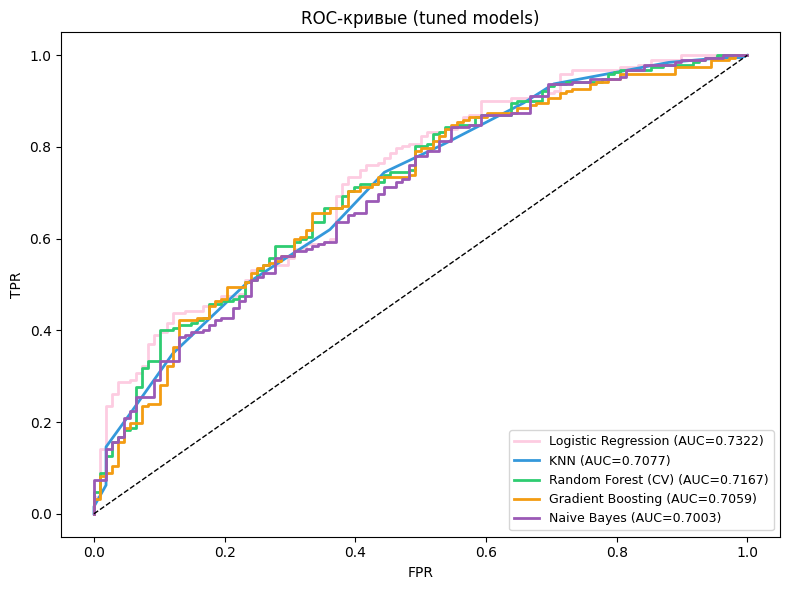

             Модель    AUC
Logistic Regression 0.7322
 Random Forest (CV) 0.7167
                KNN 0.7077
  Gradient Boosting 0.7059
        Naive Bayes 0.7003


In [42]:
plt.figure(figsize=(8, 6))
colors = ["#FDCCE1", "#3498db", "#2ecc71", "#f39c12", "#9b59b6"]
 
auc_rows = []
for i, (name, info) in enumerate(results.items()):
    _, Xte = get_Xy(info["scaled"])
    proba  = info["model"].predict_proba(Xte)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, color=colors[i], lw=2, label=f"{name} (AUC={auc:.4f})")
    auc_rows.append({"Модель": name, "AUC": round(auc, 4)})
 
plt.plot([0,1],[0,1], "k--", lw=1)
plt.xlabel("FPR"); plt.ylabel("TPR")
plt.title("ROC-кривые (tuned models)")
plt.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()
# plt.savefig("roc_curves.png", dpi=150)
# plt.close()
# print("ROC сохранён: roc_curves.png")
print(pd.DataFrame(auc_rows).sort_values("AUC", ascending=False).to_string(index=False))

## 3.5


Лучшая модель по AUC: Logistic Regression

Матрица ошибок (порог=0.5):
           Pred=0    Pred=1
True=0     TN=  54   FP=  54
True=1     FN=  36   TP= 156

Accuracy:  0.7000
Precision: 0.7429
Recall:    0.8125
F1:        0.7761


/Users/georgiaatkinson/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/georgiaatkinson/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/georgiaatkinson/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


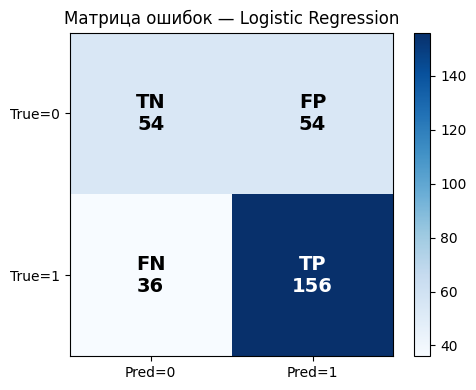

In [43]:
best_name = max(auc_rows, key=lambda r: r["AUC"])["Модель"]
best_info = results[best_name]
_, Xte_best = get_Xy(best_info["scaled"])
y_pred_best = best_info["model"].predict(Xte_best)
 
cm = confusion_matrix(y_test, y_pred_best)
tn, fp, fn, tp = cm.ravel()
 
print(f"\nЛучшая модель по AUC: {best_name}")
print(f"\nМатрица ошибок (порог=0.5):")
print(f"           Pred=0    Pred=1")
print(f"True=0     TN={tn:4d}   FP={fp:4d}")
print(f"True=1     FN={fn:4d}   TP={tp:4d}")
print(f"\nAccuracy:  {accuracy_score(y_test, y_pred_best):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_best):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_best):.4f}")
print(f"F1:        {f1_score(y_test, y_pred_best):.4f}")
 
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(["Pred=0","Pred=1"]); ax.set_yticklabels(["True=0","True=1"])
labels = [["TN","FP"],["FN","TP"]]
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{labels[i][j]}\n{cm[i,j]}", ha="center", va="center",
                color="white" if cm[i,j] > cm.max()/2 else "black", fontsize=14, fontweight="bold")
ax.set_title(f"Матрица ошибок — {best_name}")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## 3.6

In [44]:
proba_best = best_info["model"].predict_proba(Xte_best)[:, 1]
 
thresh_rows = []
for thresh in [0.3, 0.5, 0.7]:
    preds = (proba_best >= thresh).astype(int)
    tn_, fp_, fn_, tp_ = confusion_matrix(y_test, preds).ravel()
    thresh_rows.append({
        "Порог":    thresh,
        "ACC":      round(accuracy_score(y_test, preds), 4),
        "Precision":round(precision_score(y_test, preds, zero_division=0), 4),
        "Recall":   round(recall_score(y_test, preds, zero_division=0), 4),
        "F1":       round(f1_score(y_test, preds, zero_division=0), 4),
        "TP": int(tp_), "TN": int(tn_), "FP": int(fp_), "FN": int(fn_),
    })
 
thresh_df = pd.DataFrame(thresh_rows)
print(f"\nМодель: {best_name}\n")
print(thresh_df.to_string(index=False))


Модель: Logistic Regression

 Порог    ACC  Precision  Recall     F1  TP  TN  FP  FN
   0.3 0.6800     0.6690  0.9896 0.7983 190  14  94   2
   0.5 0.7000     0.7429  0.8125 0.7761 156  54  54  36
   0.7 0.5867     0.8269  0.4479 0.5811  86  90  18 106


/Users/georgiaatkinson/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/georgiaatkinson/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/georgiaatkinson/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


## 3.7

/Users/georgiaatkinson/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/georgiaatkinson/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/georgiaatkinson/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/georgiaatkinson/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/georgiaatkinson/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/georgiaatkinson/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b




             Модель  Опт. порог (train)  Прибыль (порог=0.5)  Прибыль (опт. порог)  Прирост
Logistic Regression                0.35                61800                 77700    15900
                KNN                0.36                69500                 75900     6400
        Naive Bayes                0.20                46800                 75100    28300
 Random Forest (CV)                0.45                67600                 72300     4700
  Gradient Boosting                0.44                59400                 67300     7900


/Users/georgiaatkinson/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/georgiaatkinson/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/georgiaatkinson/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


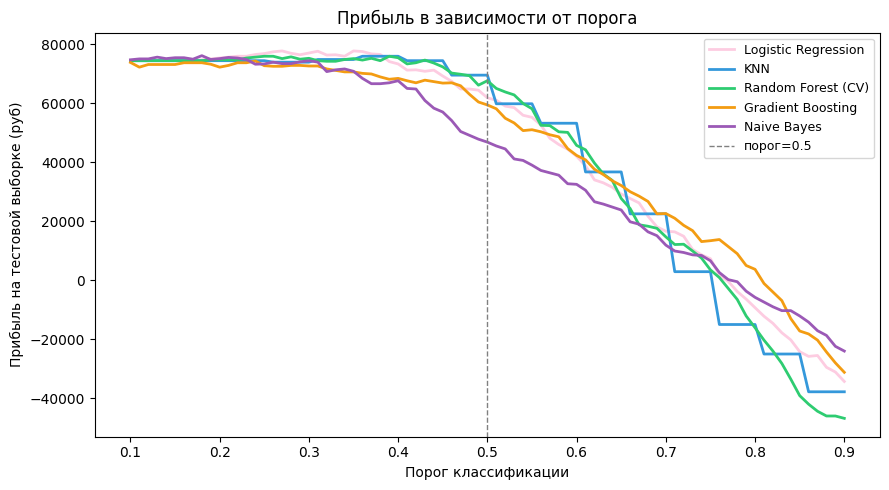

In [45]:
thresholds_scan = np.arange(0.10, 0.91, 0.01)
profit_rows = []
 
for name, info in results.items():
    Xtr, Xte = get_Xy(info["scaled"])
    proba_tr  = info["model"].predict_proba(Xtr)[:, 1]
    proba_te  = info["model"].predict_proba(Xte)[:, 1]
 
    best_thr = max(thresholds_scan,
                   key=lambda t: compute_profit(y_train, proba_tr, t))
 
    profit_05  = compute_profit(y_test, proba_te, 0.50)
    profit_opt = compute_profit(y_test, proba_te, best_thr)
 
    profit_rows.append({
        "Модель":               name,
        "Опт. порог (train)":   round(float(best_thr), 2),
        "Прибыль (порог=0.5)":  profit_05,
        "Прибыль (опт. порог)": profit_opt,
        "Прирост":              profit_opt - profit_05,
    })
 
profit_df = pd.DataFrame(profit_rows).sort_values("Прибыль (опт. порог)", ascending=False)
print("\n")
print(profit_df.to_string(index=False))
 
plt.figure(figsize=(9, 5))
for i, (name, info) in enumerate(results.items()):
    _, Xte = get_Xy(info["scaled"])
    proba_te = info["model"].predict_proba(Xte)[:, 1]
    profits  = [compute_profit(y_test, proba_te, t) for t in thresholds_scan]
    plt.plot(thresholds_scan, profits, color=colors[i], lw=2, label=name)
 
plt.axvline(0.5, color="grey", ls="--", lw=1, label="порог=0.5")
plt.xlabel("Порог классификации")
plt.ylabel("Прибыль на тестовой выборке (руб)")
plt.title("Прибыль в зависимости от порога")
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

---

In [ ]:
# ── Сохраняем файлы ────────────────────────────────────────────────
df.to_csv("data_full.csv", index=False)
train_df.to_csv("data_train.csv", index=False)
test_df.to_csv("data_test.csv", index=False)

# ── Описательные статистики ────────────────────────────────────────
print("=" * 60)
print(f"  ДАННЫЕ СГЕНЕРИРОВАНЫ  |  N = {N}")
print("=" * 60)

print("\n📊 НЕПРЕРЫВНЫЕ ПЕРЕМЕННЫЕ:")
cont_vars = ["wage", "experience", "education", "motivation"]
stats = df[cont_vars].agg(["mean", "std", "median", "min", "max"]).T
stats.columns = ["Mean", "Std", "Median", "Min", "Max"]
print(stats.round(2).to_string())

print("\n🔵 БИНАРНЫЕ ПЕРЕМЕННЫЕ:")
bin_vars = ["training", "isMale", "isUrban", "isAge50"]
for v in bin_vars:
    ones = df[v].sum()
    share = df[v].mean()
    print(f"  {v:<12} доля = {share:.3f}  |  единиц = {ones}  |  нулей = {N - ones}")

print("\n🔗 КОРРЕЛЯЦИОННАЯ МАТРИЦА (наблюдаемые переменные):")
obs_vars = ["wage", "training", "isMale", "experience", "education", "isUrban", "isAge50"]
print(df[obs_vars].corr().round(3).to_string())

print("\n✂️  РАЗБИЕНИЕ ВЫБОРКИ:")
print(f"  Train: {len(train_df)} наблюдений (75%)")
print(f"  Test:  {len(test_df)} наблюдений  (25%)")

print("\n✅ Файлы сохранены: data_full.csv | data_train.csv | data_test.csv")

  ДАННЫЕ СГЕНЕРИРОВАНЫ  |  N = 1200

📊 НЕПРЕРЫВНЫЕ ПЕРЕМЕННЫЕ:
               Mean     Std   Median     Min      Max
wage        2422.34  730.66  2318.02  790.63  6752.59
experience    10.28    4.86    10.15    0.00    26.00
education     14.03    2.92    14.05    8.00    22.00
motivation    -0.03    1.01    -0.05   -2.90     3.10

🔵 БИНАРНЫЕ ПЕРЕМЕННЫЕ:
  training     доля = 0.642  |  единиц = 770  |  нулей = 430
  isMale       доля = 0.510  |  единиц = 612  |  нулей = 588
  isUrban      доля = 0.623  |  единиц = 748  |  нулей = 452
  isAge50      доля = 0.298  |  единиц = 358  |  нулей = 842

🔗 КОРРЕЛЯЦИОННАЯ МАТРИЦА (наблюдаемые переменные):
             wage  training  isMale  experience  education  isUrban  isAge50
wage        1.000     0.296   0.274       0.319      0.611    0.150    0.040
training    0.296     1.000   0.050      -0.036      0.130    0.036    0.149
isMale      0.274     0.050   1.000       0.001      0.029    0.022   -0.013
experience  0.319    -0.036   0.001    